In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.optim as optim
from tqdm.notebook import tqdm
import time
from sklearn.metrics import confusion_matrix
import seaborn as sns
import random
from functools import partial
from einops import rearrange, repeat
from einops.layers.torch import Rearrange, Reduce

In [2]:
print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")

PyTorch version: 2.6.0+cu124
Torchvision version: 0.21.0+cu124


In [ ]:
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4), 
    transforms.RandomHorizontalFlip(p=0.5), 
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1), 
    transforms.ToTensor(), # Convert PIL Image to PyTorch Tensor (scales pixels to [0, 1])
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], #  using CIFAR-10 mean
                         std=[0.2023, 0.1994, 0.2010])  #  using CIFAR-10 std
])

In [ ]:
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                         std=[0.2023, 0.1994, 0.2010])
])

In [ ]:
print("Loading Training Data...")
train_dataset = torchvision.datasets.CIFAR10(root='./data',
                                             train=True,
                                             download=True,
                                             transform=train_transform)
print("Training Data Loaded.")

print("Loading Test Data...")
test_dataset = torchvision.datasets.CIFAR10(root='./data',
                                            train=False,
                                            download=True,
                                            transform=test_transform)
print("Test Data Loaded.")

batch_size = 128 

train_loader = torch.utils.data.DataLoader(train_dataset,
                                           batch_size=batch_size,
                                           shuffle=True,
                                           num_workers=8) 

test_loader = torch.utils.data.DataLoader(test_dataset,
                                          batch_size=batch_size,
                                          shuffle=False, 
                                          num_workers=4)

classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

print(f"\nNumber of training samples: {len(train_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of test batches: {len(test_loader)}")
print(f"Batch size: {batch_size}")
print(f"Image shape: {train_dataset[0][0].shape}")
print(f"Classes: {classes}")

Loading Training Data...


100%|██████████| 170M/170M [00:13<00:00, 12.6MB/s]


Training Data Loaded.
Loading Test Data...
Test Data Loaded.

Number of training samples: 50000
Number of test samples: 10000
Number of training batches: 391
Number of test batches: 79
Batch size: 128
Image shape: torch.Size([3, 32, 32])
Classes: ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


In [ ]:
def imshow(img):
    """Helper function to unnormalize and display an image"""
    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.2023, 0.1994, 0.2010])
    img = img.numpy().transpose((1, 2, 0)) # Convert from Tensor image (C, H, W) to NumPy (H, W, C)
    img = std * img + mean # Unnormalize
    img = np.clip(img, 0, 1) # Clip values to be between 0 and 1
    plt.imshow(img)


Visualizing a batch of augmented training images...


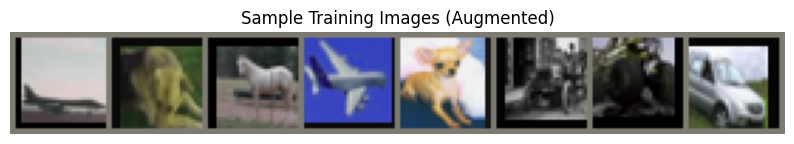

Labels: plane dog   horse plane dog   car   truck car  

Dataset loading and augmentation setup complete.


In [ ]:
print("\nVisualizing a batch of augmented training images...")
dataiter = iter(train_loader)
images, labels = next(dataiter)

plt.figure(figsize=(10, 5))
imshow(torchvision.utils.make_grid(images[:8])) 
plt.title("Sample Training Images (Augmented)")
plt.axis('off')
plt.show()

print('Labels:', ' '.join(f'{classes[labels[j]]:5s}' for j in range(8)))

print("\nDataset loading and augmentation setup complete.")

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

In [ ]:
class ConvLSTMCell(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size, bias):
        super(ConvLSTMCell, self).__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.kernel_size = kernel_size
        self.padding = kernel_size[0] // 2, kernel_size[1] // 2
        self.bias = bias
        self.conv = nn.Conv2d(in_channels=self.input_dim + self.hidden_dim,
                              out_channels=4 * self.hidden_dim,
                              kernel_size=self.kernel_size,
                              padding=self.padding,
                              bias=self.bias)

    def forward(self, input_tensor, cur_state):
        h_cur, c_cur = cur_state
        combined = torch.cat([input_tensor, h_cur], dim=1)
        combined_conv = self.conv(combined)
        cc_i, cc_f, cc_o, cc_g = torch.split(combined_conv, self.hidden_dim, dim=1)
        i = torch.sigmoid(cc_i)
        f = torch.sigmoid(cc_f)
        o = torch.sigmoid(cc_o)
        g = torch.tanh(cc_g)
        c_next = f * c_cur + i * g
        h_next = o * torch.tanh(c_next)
        return h_next, c_next

    def init_hidden(self, batch_size, image_size):
        height, width = image_size
        device = self.conv.weight.device
        return (torch.zeros(batch_size, self.hidden_dim, height, width, device=device),
                torch.zeros(batch_size, self.hidden_dim, height, width, device=device))

class ConvLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size, num_layers,
                 batch_first=False, bias=True, return_all_layers=False):
        super(ConvLSTM, self).__init__()
        self._check_kernel_size_consistency(kernel_size)
        kernel_size = self._extend_for_multilayer(kernel_size, num_layers)
        hidden_dim = self._extend_for_multilayer(hidden_dim, num_layers)
        if not len(kernel_size) == len(hidden_dim) == num_layers:
            raise ValueError('Inconsistent list length.')

        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.kernel_size = kernel_size
        self.num_layers = num_layers
        self.batch_first = batch_first
        self.bias = bias
        self.return_all_layers = return_all_layers

        cell_list = []
        for i in range(0, self.num_layers):
            cur_input_dim = self.input_dim if i == 0 else self.hidden_dim[i - 1]
            cell_list.append(ConvLSTMCell(input_dim=cur_input_dim,
                                          hidden_dim=self.hidden_dim[i],
                                          kernel_size=self.kernel_size[i],
                                          bias=self.bias))
        self.cell_list = nn.ModuleList(cell_list)

    def forward(self, input_tensor, hidden_state=None):
        expected_device = self.cell_list[0].conv.weight.device
        if input_tensor.device != expected_device:
             input_tensor = input_tensor.to(expected_device)

        if not self.batch_first:
            input_tensor = input_tensor.permute(1, 0, 2, 3, 4)

        b, seq_len, _, h, w = input_tensor.size()

        if hidden_state is None:
            hidden_state = self._init_hidden(batch_size=b, image_size=(h, w))
        else:
             hidden_state = [(h.to(expected_device), c.to(expected_device)) for h, c in hidden_state]


        layer_output_list = []
        last_state_list = []
        cur_layer_input = input_tensor

        for layer_idx in range(self.num_layers):
            h, c = hidden_state[layer_idx]
            output_inner = []
            for t in range(seq_len):
                h, c = self.cell_list[layer_idx](input_tensor=cur_layer_input[:, t, :, :, :],
                                                 cur_state=[h, c]) # h,c are already on correct device
                output_inner.append(h)

            layer_output = torch.stack(output_inner, dim=1)
            cur_layer_input = layer_output
            layer_output_list.append(layer_output)
            last_state_list.append([h, c])

        if not self.return_all_layers:
            layer_output_list = layer_output_list[-1:]
            last_state_list = last_state_list[-1:]

        return layer_output_list, last_state_list

    def _init_hidden(self, batch_size, image_size):
        init_states = []
        device = next(self.parameters()).device
        for i in range(self.num_layers):
             init_states.append(self.cell_list[i].init_hidden(batch_size, image_size))
        return init_states


    @staticmethod
    def _check_kernel_size_consistency(kernel_size):
        if not (isinstance(kernel_size, tuple) or
                (isinstance(kernel_size, list) and all([isinstance(elem, tuple) for elem in kernel_size]))):
            raise ValueError('`kernel_size` must be tuple or list of tuples')

    @staticmethod
    def _extend_for_multilayer(param, num_layers):
        if not isinstance(param, list):
            param = [param] * num_layers
        return param

In [ ]:
class CIFAR_ConvLSTM_Classifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size, num_layers, num_classes):
        super(CIFAR_ConvLSTM_Classifier, self).__init__()
        self.num_layers = num_layers 
        self.hidden_dim = hidden_dim 

        self.convlstm = ConvLSTM(input_dim=input_dim,
                                 hidden_dim=hidden_dim,
                                 kernel_size=kernel_size,
                                 num_layers=num_layers,
                                 batch_first=True,
                                 bias=True,
                                 return_all_layers=False)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        if isinstance(hidden_dim, list):
            final_hidden_dim = hidden_dim[-1]
        else: # If hidden_dim is an int (single layer)
            final_hidden_dim = hidden_dim

        self.fc = nn.Linear(final_hidden_dim, num_classes)

    def forward(self, x):
        x = x.unsqueeze(1) 

        # Pass through ConvLSTM
        _, last_state_list = self.convlstm(x)

        # Get the last hidden state h: (B, C_hid_last, H, W)
        h_last = last_state_list[0][0]

        # Apply Global Average Pooling: -> (B, C_hid_last, 1, 1)
        pooled_output = self.avgpool(h_last)

        # Flatten: -> (B, C_hid_last)
        flattened_output = torch.flatten(pooled_output, 1)

        # Classifier
        logits = self.fc(flattened_output) # -> (B, num_classes)
        return logits

In [ ]:
cifar_mean = [0.4914, 0.4822, 0.4465]
cifar_std = [0.2023, 0.1994, 0.2010]

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=cifar_mean, std=cifar_std)
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=cifar_mean, std=cifar_std)
])

In [ ]:
try:
    train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=False, transform=train_transform)
    test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=False, transform=test_transform)
except RuntimeError:
    print("Downloading dataset...")
    train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
    test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)

In [ ]:
BATCH_SIZE = 2048 
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=128, pin_memory=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=128, pin_memory=True)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
NUM_CLASSES = len(classes)
INPUT_DIM = 3 # Input channels (RGB)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [ ]:
def train_eval_model(hparams, n_epochs, train_loader, test_loader, device, verbose=True):
    """Trains and evaluates a model for one trial."""
    model = CIFAR_ConvLSTM_Classifier(
        input_dim=INPUT_DIM,
        hidden_dim=hparams['hidden_dim'],
        kernel_size=hparams['kernel_size'],
        num_layers=hparams['num_layers'],
        num_classes=NUM_CLASSES
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=hparams['lr'], weight_decay=hparams['weight_decay'])
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs, eta_min=1e-6)

    best_val_acc = 0.0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(n_epochs):
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0
        if verbose:
            pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{n_epochs} [Train]", leave=False)
        else:
            pbar = train_loader

        for inputs, labels in pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()
            if verbose:
                 pbar.set_postfix(loss=loss.item(), acc=f"{(predicted == labels).sum().item()/labels.size(0):.3f}")

        epoch_train_loss = running_loss / total_train
        epoch_train_acc = correct_train / total_train
        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)

        model.eval()
        running_loss = 0.0
        correct_val = 0
        total_val = 0
        if verbose:
            pbar_val = tqdm(test_loader, desc=f"Epoch {epoch+1}/{n_epochs} [Val]", leave=False)
        else:
            pbar_val = test_loader

        with torch.no_grad():
            for inputs, labels in pbar_val:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                running_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()
                if verbose:
                    pbar_val.set_postfix(loss=loss.item(), acc=f"{(predicted == labels).sum().item()/labels.size(0):.3f}")


        epoch_val_loss = running_loss / total_val
        epoch_val_acc = correct_val / total_val
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)

        if verbose:
             current_lr = optimizer.param_groups[0]['lr']
             print(f"Epoch {epoch+1}/{n_epochs} - "
                   f"Tr Loss: {epoch_train_loss:.4f}, Tr Acc: {epoch_train_acc:.4f} | "
                   f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f} | "
                   f"LR: {current_lr:.6f}")

        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc

        scheduler.step() 

    return best_val_acc, history, model 

PyTorch version: 2.6.0+cu124
Torchvision version: 0.21.0+cu124
Loading Data...
Data loaded. Train samples: 50000, Test samples: 10000
Using device: cuda

--- Starting Hyperparameter Optimization (Random Search) ---

--- HPO Trial 1/5 ---
Sampled Hyperparameters: {'hidden_dim': [32, 32], 'num_layers': 2, 'kernel_size': [(5, 5), (5, 5)], 'lr': 0.0029712721228815214, 'weight_decay': 1.1299830769305084e-05}


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 128 worker processes in total. Our suggested max number of worker in current system is 12, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Trial 1 finished. Final Validation Accuracy: 0.3406 (Duration: 173.14s)

--- HPO Trial 2/5 ---
Sampled Hyperparameters: {'hidden_dim': [32, 32], 'num_layers': 2, 'kernel_size': [(3, 3), (3, 3)], 'lr': 0.00011220740288380038, 'weight_decay': 2.7598230915285763e-05}
Trial 2 finished. Final Validation Accuracy: 0.1367 (Duration: 165.14s)

--- HPO Trial 3/5 ---
Sampled Hyperparameters: {'hidden_dim': [32, 32], 'num_layers': 2, 'kernel_size': [(5, 5), (5, 5)], 'lr': 0.00011470819313402349, 'weight_decay': 0.00019942007514013244}
Trial 3 finished. Final Validation Accuracy: 0.1794 (Duration: 176.97s)

--- HPO Trial 4/5 ---
Sampled Hyperparameters: {'hidden_dim': [32, 32], 'num_layers': 2, 'kernel_size': [(3, 3), (3, 3)], 'lr': 0.006086381003274659, 'weight_decay': 0.00010249686360134877}
Trial 4 finished. Final Validation Accuracy: 0.3241 (Duration: 166.44s)

--- HPO Trial 5/5 ---
Sampled Hyperparameters: {'hidden_dim': [96, 96], 'num_layers': 2, 'kernel_size': [(5, 5), (5, 5)], 'lr': 0.0001

Epoch 1/25 [Train]:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 1/25 [Val]:   0%|          | 0/5 [00:00<?, ?it/s]

...

Epoch 24/25 [Val]:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 24/25 - Tr Loss: 1.5926, Tr Acc: 0.4205 | Val Loss: 1.5661, Val Acc: 0.4150 | LR: 0.000048


Epoch 25/25 [Train]:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 25/25 [Val]:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 25/25 - Tr Loss: 1.5925, Tr Acc: 0.4153 | Val Loss: 1.5671, Val Acc: 0.4149 | LR: 0.000013

--- Final Training Finished --- (Duration: 9.49 minutes)
Final Model Validation Accuracy: 0.4154


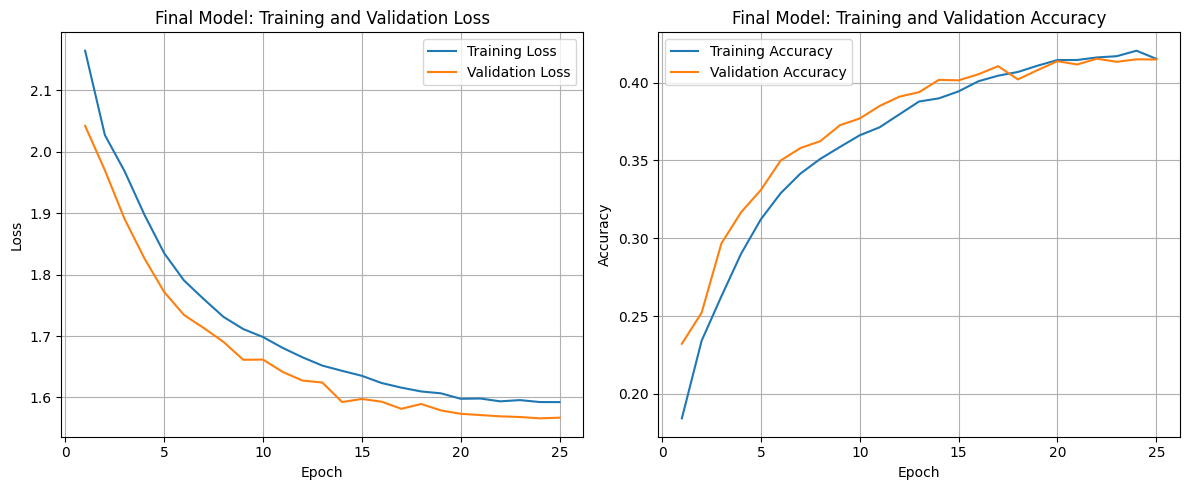


Generating Confusion Matrix for Final Model...


Confusion Matrix:   0%|          | 0/5 [00:00<?, ?it/s]

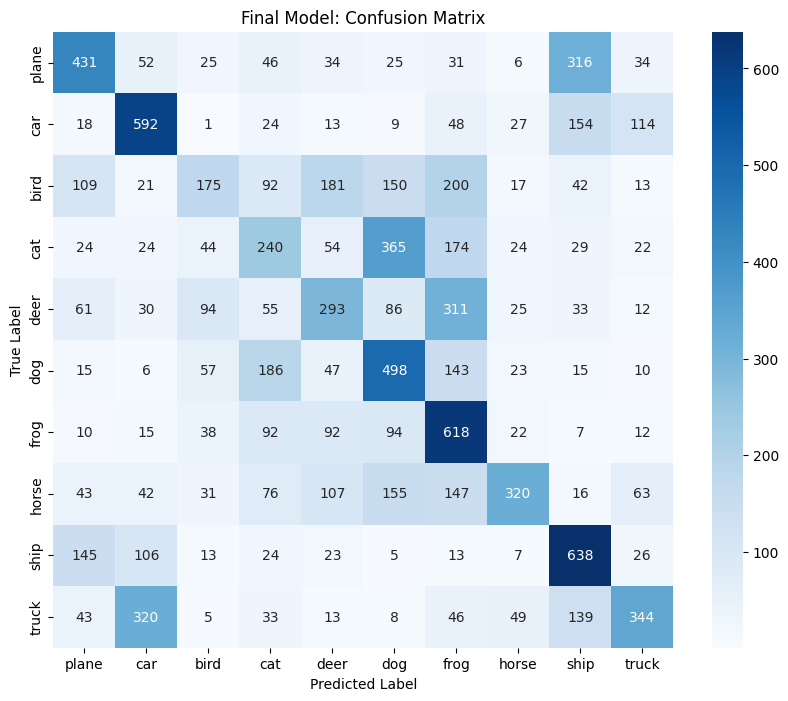


Visualizing Sample Predictions from Final Model...


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 128 worker processes in total. Our suggested max number of worker in current system is 12, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


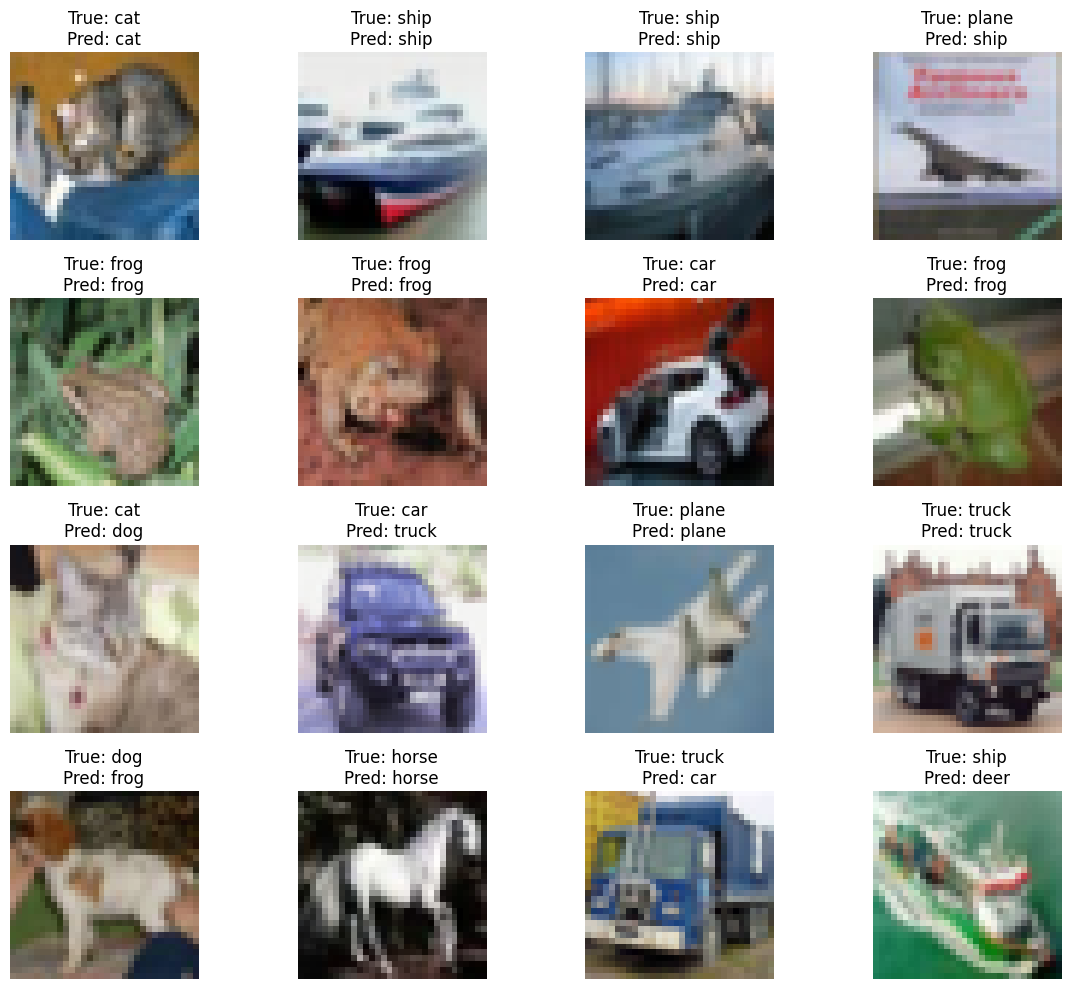


Script finished.


In [ ]:
print(f"Using device: {device}")

print("\n--- Starting Hyperparameter Optimization (Random Search) ---")

param_space = {
    'hidden_dim': [32, 64, 96],      
    'num_layers': [1, 2],             
    'kernel_size': [(3, 3), (5, 5)],  
    'lr': [10**random.uniform(-4, -2) for _ in range(10)], 
    'weight_decay': [10**random.uniform(-5, -3) for _ in range(10)] 
}

N_TRIALS = 5 # Number of random combinations to try
EPOCHS_PER_TRIAL = 8 # Fewer epochs for faster HPO

results = []
hpo_start_time = time.time()

for i in range(N_TRIALS):
    print(f"\n--- HPO Trial {i+1}/{N_TRIALS} ---")
    hparams = {
        'hidden_dim': random.choice(param_space['hidden_dim']),
        'num_layers': random.choice(param_space['num_layers']),
        'kernel_size': random.choice(param_space['kernel_size']),
        'lr': random.choice(param_space['lr']),
        'weight_decay': random.choice(param_space['weight_decay']),
    }


    if hparams['num_layers'] > 1:
         hparams['hidden_dim'] = [hparams['hidden_dim']] * hparams['num_layers']
         hparams['kernel_size'] = [hparams['kernel_size']] * hparams['num_layers']
    else:
         if isinstance(hparams['hidden_dim'], list): hparams['hidden_dim'] = hparams['hidden_dim'][0]


    print(f"Sampled Hyperparameters: {hparams}")

    trial_start_time = time.time()
    final_val_acc, _, _ = train_eval_model(
        hparams, EPOCHS_PER_TRIAL, train_loader, test_loader, device, verbose=False
    )
    trial_duration = time.time() - trial_start_time

    print(f"Trial {i+1} finished. Final Validation Accuracy: {final_val_acc:.4f} (Duration: {trial_duration:.2f}s)")
    results.append({'hparams': hparams, 'val_accuracy': final_val_acc})

hpo_duration = time.time() - hpo_start_time
print(f"\n--- Hyperparameter Optimization Finished --- (Total Duration: {hpo_duration/60:.2f} minutes)")

best_trial = max(results, key=lambda x: x['val_accuracy'])
best_hparams = best_trial['hparams']
best_val_accuracy = best_trial['val_accuracy']

print("\n--- Best Hyperparameters Found ---")
print(f"Validation Accuracy: {best_val_accuracy:.4f}")
print(f"Hyperparameters: {best_hparams}")


print("\n--- Starting Final Training with Best Hyperparameters ---")
NUM_EPOCHS_FINAL = 25 
final_training_start_time = time.time()

best_val_acc_final, final_history, final_model = train_eval_model(
    best_hparams,
    NUM_EPOCHS_FINAL,
    train_loader,
    test_loader,
    device,
    verbose=True 
)

final_training_duration = time.time() - final_training_start_time
print(f"\n--- Final Training Finished --- (Duration: {final_training_duration/60:.2f} minutes)")
print(f"Final Model Validation Accuracy: {best_val_acc_final:.4f}")

plt.figure(figsize=(12, 5))
epochs_range = range(1, NUM_EPOCHS_FINAL + 1)

plt.subplot(1, 2, 1)
plt.plot(epochs_range, final_history['train_loss'], label='Training Loss')
plt.plot(epochs_range, final_history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Final Model: Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, final_history['train_acc'], label='Training Accuracy')
plt.plot(epochs_range, final_history['val_acc'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Final Model: Training and Validation Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("\nGenerating Confusion Matrix for Final Model...")
final_model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Confusion Matrix"):
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = final_model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Final Model: Confusion Matrix')
plt.show()

def imshow_results(img, title):
    """Helper function to unnormalize and display an image with title"""
    img = img.cpu().numpy().transpose((1, 2, 0))
    mean = np.array(cifar_mean)
    std = np.array(cifar_std)
    img = std * img + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.title(title)
    plt.axis('off')

print("\nVisualizing Sample Predictions from Final Model...")
final_model.eval()
dataiter = iter(test_loader)
try:
    images, labels = next(dataiter)
    images, labels = images.to(device), labels.to(device)

    outputs = final_model(images)
    _, predicted = torch.max(outputs, 1)

    plt.figure(figsize=(12, 10)) # Adjusted size for better layout
    num_images_to_show = min(16, len(images)) # Show up to 16 images
    for i in range(num_images_to_show):
        plt.subplot(4, 4, i+1)
        title = f"True: {classes[labels[i]]}\nPred: {classes[predicted[i]]}"
        imshow_results(images[i], title)

    plt.tight_layout()
    plt.show()

except StopIteration:
    print("Test loader iterator exhausted.")

print("\nScript finished.")

In [ ]:
import gc

gc.collect()
torch.cuda.empty_cache()

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

In [ ]:
# helpers
def exists(val):
    return val is not None

def default(val, d):
    return val if exists(val) else d

def cast_tuple(val, length = 1):
    return val if isinstance(val, tuple) else ((val,) * length)

# helper classes
class Residual(nn.Module):
    def __init__(self, dim, fn):
        super().__init__()
        self.fn = fn

    def forward(self, x):
        return self.fn(x) + x

class FeedForward(nn.Module):
    def __init__(self, dim, mult = 4, dropout = 0.):
        super().__init__()
        inner_dim = int(dim * mult)
        self.net = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, inner_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(inner_dim, dim),
            nn.Dropout(dropout)
        )
    def forward(self, x):
        return self.net(x)

# MBConv
class SqueezeExcitation(nn.Module):
    def __init__(self, dim, shrinkage_rate = 0.25):
        super().__init__()
        hidden_dim = int(dim * shrinkage_rate)

        self.gate = nn.Sequential(
            Reduce('b c h w -> b c', 'mean'),
            nn.Linear(dim, hidden_dim, bias = False),
            nn.SiLU(), # Using SiLU
            nn.Linear(hidden_dim, dim, bias = False),
            nn.Sigmoid(),
            Rearrange('b c -> b c 1 1')
        )

    def forward(self, x):
        return x * self.gate(x)


class MBConvResidual(nn.Module):
    def __init__(self, fn, dropout = 0.):
        super().__init__()
        self.fn = fn
        self.dropsample = Dropsample(dropout) 

    def forward(self, x):
        out = self.fn(x)
        out = self.dropsample(out)
        return out + x

class Dropsample(nn.Module):
    def __init__(self, prob = 0):
        super().__init__()
        self.prob = prob

    def forward(self, x):
        device = x.device 

        if self.prob == 0. or (not self.training):
            return x


        keep_mask = torch.rand(x.shape[0], 1, 1, 1, device=device) > self.prob

        if (1.0 - self.prob) > 1e-6:
            return x * keep_mask / (1.0 - self.prob)
        else: # Avoid division by zero or near-zero (if prob is 1 or very close)
            return x * keep_mask # Effectively drops everything if prob is 1

def MBConv(
    dim_in,
    dim_out,
    *,
    downsample,
    expansion_rate = 4,
    shrinkage_rate = 0.25,
    dropout = 0.
):
    hidden_dim = int(expansion_rate * dim_out) # Corrected: expansion based on dim_out
    stride = 2 if downsample else 1

    net = nn.Sequential(
        # Point-wise expansion
        nn.Conv2d(dim_in, hidden_dim, 1),
        nn.BatchNorm2d(hidden_dim),
        nn.GELU(), # Or SiLU/ReLU
        # Depth-wise convolution
        nn.Conv2d(hidden_dim, hidden_dim, 3, stride = stride, padding = 1, groups = hidden_dim),
        nn.BatchNorm2d(hidden_dim),
        nn.GELU(), # Or SiLU/ReLU
        # Squeeze-and-Excitation
        SqueezeExcitation(hidden_dim, shrinkage_rate = shrinkage_rate),
        # Point-wise projection
        nn.Conv2d(hidden_dim, dim_out, 1),
        nn.BatchNorm2d(dim_out)
    )

    # Skip connection if dimensions match and no downsampling
    if dim_in == dim_out and not downsample:
        net = MBConvResidual(net, dropout = dropout)

    return net

# attention related classes
class Attention(nn.Module):
    def __init__(
        self,
        dim,
        dim_head = 32,
        dropout = 0.,
        window_size = 7
    ):
        super().__init__()
        assert (dim % dim_head) == 0, 'dimension should be divisible by dimension per head'

        self.heads = dim // dim_head
        self.scale = dim_head ** -0.5

        self.norm = nn.LayerNorm(dim)
        self.to_qkv = nn.Linear(dim, dim * 3, bias = False)

        self.attend = nn.Sequential(
            nn.Softmax(dim = -1),
            nn.Dropout(dropout)
        )

        self.to_out = nn.Sequential(
            nn.Linear(dim, dim, bias = False),
            nn.Dropout(dropout)
        )

        # relative positional bias
        self.rel_pos_bias = nn.Embedding((2 * window_size - 1) ** 2, self.heads)

        pos = torch.arange(window_size)
        grid = torch.stack(torch.meshgrid(pos, pos, indexing = 'ij')) # H, W coords
        grid = rearrange(grid, 'c i j -> (i j) c') # flatten to (HW, 2)
        # Calculate relative distances: (HW, 1, 2) - (1, HW, 2) -> (HW, HW, 2)
        rel_pos = rearrange(grid, 'i ... -> i 1 ...') - rearrange(grid, 'j ... -> 1 j ...')
        # Shift to be non-negative indices
        rel_pos += window_size - 1
        # Calculate flat index: rel_y * (2W-1) + rel_x
        rel_pos_indices = (rel_pos * torch.tensor([2 * window_size - 1, 1])).sum(dim = -1)

        self.register_buffer('rel_pos_indices', rel_pos_indices, persistent = False)

    def forward(self, x):
        # Input shape: b (x y) w1 w2 d -> (batch, grid_h, grid_w, win_h, win_w, dim)
        # Or for grid attention: b (h/w1 w/w2) w1 w2 d -> (batch, num_win_h, num_win_w, win_h, win_w, dim)
        batch, grid_h, grid_w, win_h, win_w, dim_ = x.shape # Check variable names
        assert dim_ == self.norm.normalized_shape[0]
        # num_windows = grid_h * grid_w
        # window_len = win_h * win_w

        # Layer norm
        x = self.norm(x)

        # Flatten grid and windows: b (x y) (w1 w2) d -> (b*x*y) (w1*w2) d
        x = rearrange(x, 'b gh gw wh ww d -> (b gh gw) (wh ww) d')

        # Project for queries, keys, values: (b*num_win) win_len (3*dim)
        q, k, v = self.to_qkv(x).chunk(3, dim = -1)

        # Split heads: (b*num_win) h win_len d_head
        q, k, v = map(lambda t: rearrange(t, 'b n (h d) -> b h n d', h = self.heads), (q, k, v))

        # Scale
        q = q * self.scale

        # Similarity: (b*num_win) h win_len win_len
        sim = torch.einsum('b h i d, b h j d -> b h i j', q, k)

        # Add relative positional bias: retrieve biases (win_len, win_len) -> (1, win_len, win_len, h) -> (1, h, win_len, win_len)
        bias = self.rel_pos_bias(self.rel_pos_indices) # (win_len, win_len, heads)
        bias = rearrange(bias, 'i j h -> 1 h i j')
        sim = sim + bias

        # Attention
        attn = self.attend(sim)

        # Aggregate values: (b*num_win) h win_len d_head
        out = torch.einsum('b h i j, b h j d -> b h i d', attn, v)

        # Merge heads: (b*num_win) win_len (h*d_head = dim)
        out = rearrange(out, 'b h n d -> b n (h d)')

        # Combine heads out projection: (b*num_win) win_len dim
        out = self.to_out(out)

        # Unflatten windows and grid: (b*num_win) (wh ww) d -> b gh gw wh ww d
        out = rearrange(out, '(b gh gw) (wh ww) d -> b gh gw wh ww d', gh=grid_h, gw=grid_w, wh=win_h, ww=win_w)

        return out


class MaxViT(nn.Module):
    def __init__(
        self,
        *,
        num_classes,
        dim,                  # Base dimension
        depth,                # Tuple of depths per stage (e.g., (2, 2, 6, 2))
        dim_head = 32,        # Dimension of each attention head
        dim_conv_stem = None, # Dimension of the conv stem, defaults to dim
        window_size = 7,      # Attention window size
        mbconv_expansion_rate = 4, # MBConv expansion factor
        mbconv_shrinkage_rate = 0.25,# Squeeze-and-Excitation reduction factor
        dropout = 0.1,        # Dropout rate
        channels = 3          # Input channels
    ):
        super().__init__()
        assert isinstance(depth, tuple), 'depth needs to be tuple of integers indicating number of transformer blocks at that stage'
        assert dim % dim_head == 0, 'dimension must be divisible by dimension head'

        # convolutional stem
        dim_conv_stem = default(dim_conv_stem, dim // 2) # Often starts smaller

        self.conv_stem = nn.Sequential(
            # Downsample by 2
            nn.Conv2d(channels, dim_conv_stem, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(dim_conv_stem), # Added BatchNorm
            nn.GELU(), # Added Activation
            # Keep spatial size for CIFAR 32x32 -> 16x16 stem output
            nn.Conv2d(dim_conv_stem, dim_conv_stem, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(dim_conv_stem), # Added BatchNorm
            nn.GELU() # Added Activation
        )

        # variables
        num_stages = len(depth)

        # dimensions per stage. Start stem dim, then double dim for each subsequent stage.
        dims = tuple(map(lambda i: (2 ** i) * dim, range(num_stages)))
        dims = (dim_conv_stem, *dims) # Prepend stem dimension
        dim_pairs = tuple(zip(dims[:-1], dims[1:]))

        self.layers = nn.ModuleList([])

        # shorthand for window size
        w = window_size

        # iterate through stages
        for ind, ((layer_dim_in, layer_dim), layer_depth) in enumerate(zip(dim_pairs, depth)):
            for stage_ind in range(layer_depth):
                is_first = stage_ind == 0
                stage_dim_in = layer_dim_in if is_first else layer_dim

                # Use Residual wrapper consistently
                block_attention_token_mixer = Residual(dim=layer_dim, fn=Attention(dim=layer_dim, dim_head=dim_head, dropout=dropout, window_size=w))
                grid_attention_token_mixer = Residual(dim=layer_dim, fn=Attention(dim=layer_dim, dim_head=dim_head, dropout=dropout, window_size=w))
                block_feedforward = Residual(dim=layer_dim, fn=FeedForward(dim=layer_dim, dropout=dropout))
                grid_feedforward = Residual(dim=layer_dim, fn=FeedForward(dim=layer_dim, dropout=dropout))

                self.layers.append(nn.ModuleList([ # Use ModuleList for stage components
                    # MBConv block: Handles downsampling on the first block of each stage > 0
                    MBConv(
                        stage_dim_in,
                        layer_dim,
                        downsample = is_first and ind != 0, # Downsample applies only on first block of stages > 0
                        expansion_rate = mbconv_expansion_rate,
                        shrinkage_rate = mbconv_shrinkage_rate,
                        dropout=dropout # Apply dropout within MBConv residual if applicable
                    ),
                    # Block Attention sequence
                    Rearrange('b d (x w1) (y w2) -> b x y w1 w2 d', w1 = w, w2 = w),
                    block_attention_token_mixer,
                    block_feedforward,
                    Rearrange('b x y w1 w2 d -> b d (x w1) (y w2)'),

                    # Grid Attention sequence
                    # The rearrange for grid swaps spatial axes relative to windowing axes
                    Rearrange('b d (h w1) (w w2) -> b h w w1 w2 d', w1=w, w2=w),
                    grid_attention_token_mixer,
                    grid_feedforward,
                    Rearrange('b h w w1 w2 d -> b d (h w1) (w w2)'),
                ]))

        # mlp head out
        self.mlp_head = nn.Sequential(
            Reduce('b d h w -> b d', 'mean'), # Global Average Pooling
            nn.LayerNorm(dims[-1]),
            nn.Linear(dims[-1], num_classes)
        )

    def forward(self, x):
        x = self.conv_stem(x) # (B, C, H, W) -> (B, dim_conv_stem, H/2, W/2)

        for stage_block in self.layers:
            # Unpack the ModuleList for a stage
            mb_conv, block_r1, block_attn, block_ff, block_r2, grid_r1, grid_attn, grid_ff, grid_r2 = stage_block

            x = mb_conv(x)
            x = block_r1(x) # Rearrange block
            x = block_attn(x)
            x = block_ff(x)
            x = block_r2(x) # Rearrange back block
            x = grid_r1(x)  # Rearrange grid
            x = grid_attn(x)
            x = grid_ff(x)
            x = grid_r2(x)  # Rearrange back grid

        return self.mlp_head(x) # (B, num_classes)

In [ ]:
cifar_mean = [0.4914, 0.4822, 0.4465]
cifar_std = [0.2023, 0.1994, 0.2010]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(32, scale=(0.8, 1.0), ratio=(0.9, 1.1)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.15),
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=cifar_mean, std=cifar_std),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=cifar_mean, std=cifar_std)
])

In [ ]:
try:
    train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
    test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)
except Exception as e:
    print(f"Error loading or downloading CIFAR10: {e}")
    print("Please check your internet connection or the data directory.")
    exit()

In [ ]:
BATCH_SIZE = 128 # Adjust based on GPU memory
num_workers = 4 if torch.cuda.is_available() else 0
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=num_workers, pin_memory=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers, pin_memory=True)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
NUM_CLASSES = len(classes)
CHANNELS = 3

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
maxvit_config = dict(
    num_classes=NUM_CLASSES,
    dim=64,
    depth=(1, 1, 2),   
    dim_head=32,
    dim_conv_stem=32,
    window_size=4,     
    mbconv_expansion_rate=4,
    mbconv_shrinkage_rate=0.25,
    dropout=0.1,
    channels=CHANNELS
)

In [ ]:
model = MaxViT(**maxvit_config).to(device)

try:
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
except Exception as e:
    print(f"Could not calculate parameters: {e}")


NUM_EPOCHS = 60 
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)


train_losses, val_losses = [], []
train_accs, val_accs = [], []

PyTorch version: 2.6.0+cu124
Torchvision version: 0.21.0+cu124
Loading Data...
Data loaded. Train samples: 50000, Test samples: 10000
Using device: cuda

Instantiating MaxViT model...

Total Parameters: 5,962,582
Trainable Parameters: 5,962,582

--- Starting Training ---


Epoch 1/60 [Train]:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 1/60 [Val]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 1/60 - Train Loss: 1.7008, Train Acc: 0.3678 | Val Loss: 1.5109, Val Acc: 0.4571 | LR: 0.001000


Epoch 2/60 [Train]:   0%|          | 0/391 [00:00<?, ?it/s]

...

Epoch 59/60 [Val]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 59/60 - Train Loss: 0.2422, Train Acc: 0.9133 | Val Loss: 0.3497, Val Acc: 0.8865 | LR: 0.000004


Epoch 60/60 [Train]:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 60/60 [Val]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 60/60 - Train Loss: 0.2390, Train Acc: 0.9157 | Val Loss: 0.3497, Val Acc: 0.8865 | LR: 0.000002

--- Training Finished --- (Total Duration: 24.06 minutes)
Final Validation Accuracy: 0.8865


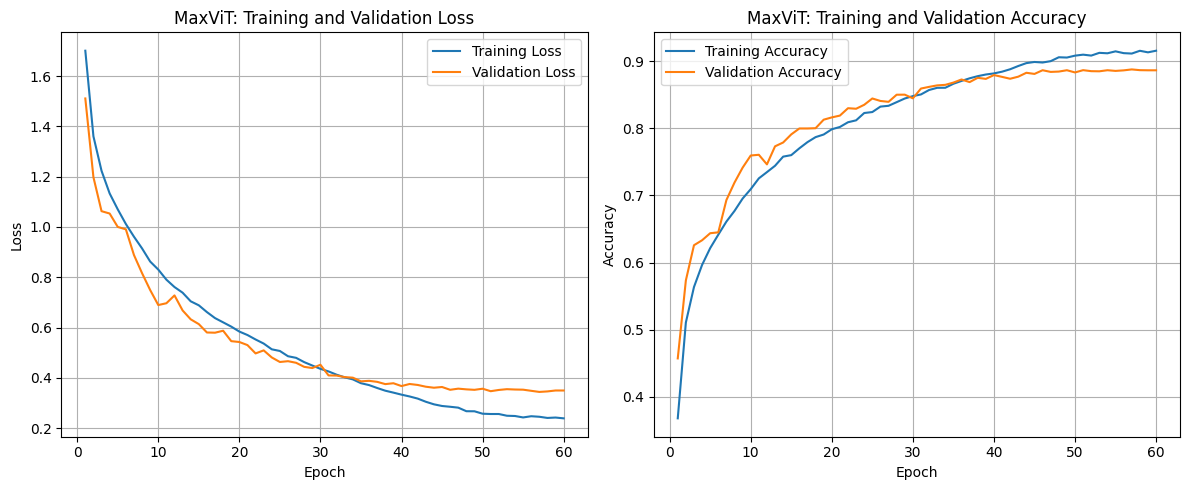


Generating Confusion Matrix...


Confusion Matrix:   0%|          | 0/79 [00:00<?, ?it/s]

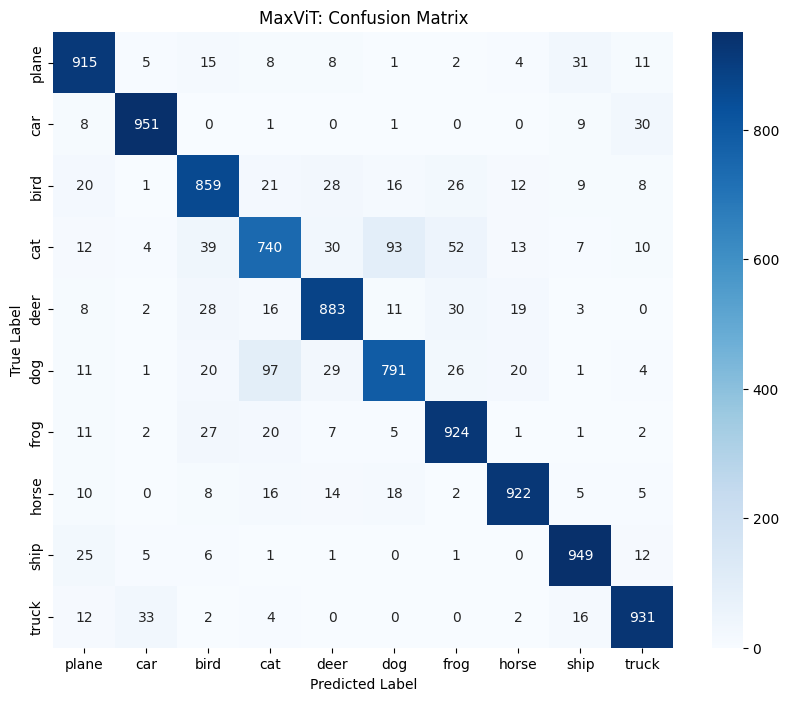


Visualizing Sample Predictions...


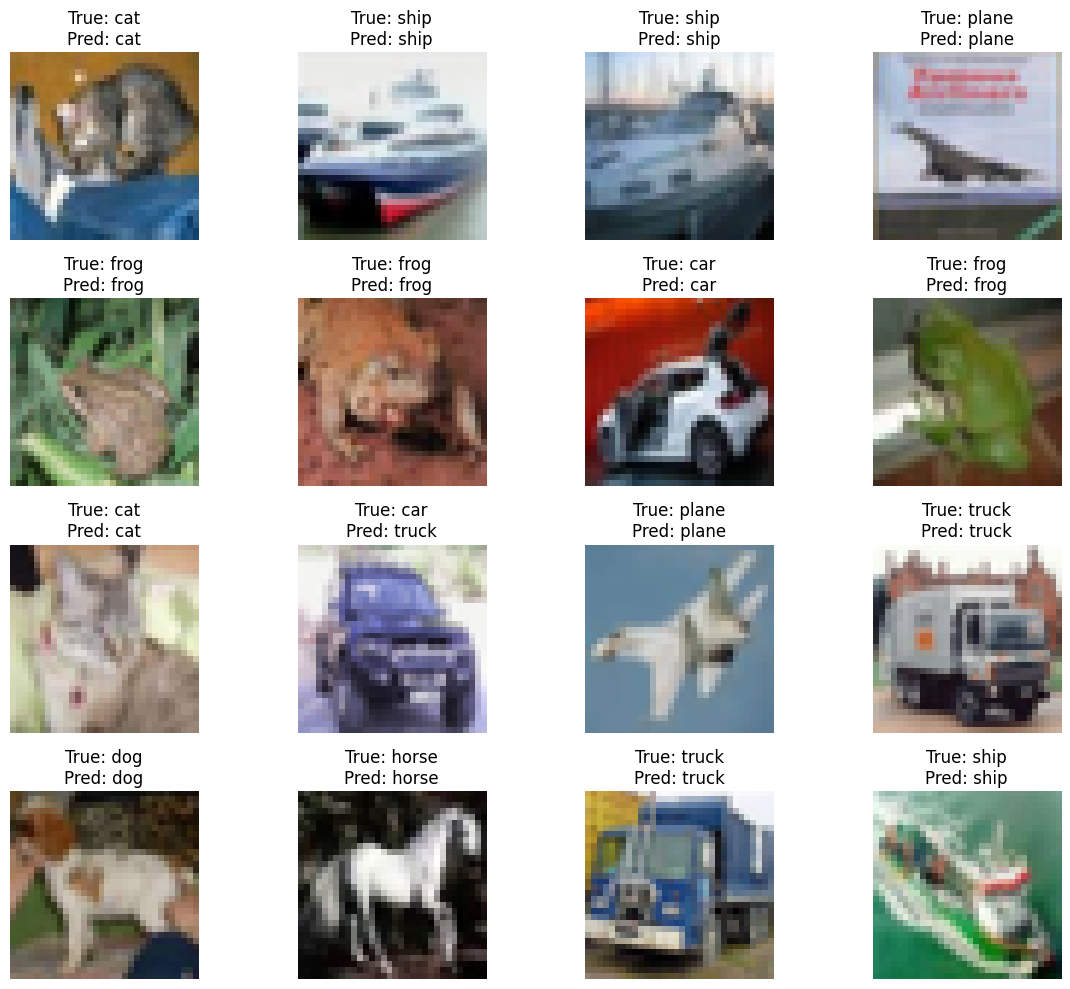


Script finished.


In [ ]:
start_time = time.time()

if not trainable_params > 0:
     exit()

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]", leave=False)
    for i, (inputs, labels) in enumerate(train_pbar):
        inputs, labels = inputs.to(device), labels.to(device)

        try:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            if torch.isnan(loss):
                print(f"NaN loss detected at epoch {epoch+1}, batch {i}. Stopping training.")
                exit()

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

            batch_acc = (predicted == labels).sum().item() / labels.size(0) if labels.size(0) > 0 else 0
            train_pbar.set_postfix(loss=loss.item(), acc=f"{batch_acc:.4f}")

        except RuntimeError as e:
            if "CUDA out of memory" in str(e):
                print(f"\nCUDA OutOfMemoryError at epoch {epoch+1}, batch {i}. Try reducing batch size or model size.")
                # Optional: clear cache and retry, but usually needs config change
                # torch.cuda.empty_cache()
            else:
                print(f"\nRuntimeError during training at epoch {epoch+1}, batch {i}: {e}")
            # Depending on the error, you might want to stop or try to continue
            exit() # Stop for most runtime errors


    # Ensure total_train is not zero before division
    epoch_train_loss = running_loss / total_train if total_train > 0 else 0
    epoch_train_acc = correct_train / total_train if total_train > 0 else 0
    train_losses.append(epoch_train_loss)
    train_accs.append(epoch_train_acc)

    # --- Validation Phase ---
    model.eval()
    running_loss = 0.0
    correct_val = 0
    total_val = 0
    val_pbar = tqdm(test_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Val]", leave=False)
    with torch.no_grad():
        for i, (inputs, labels) in enumerate(val_pbar):
            inputs, labels = inputs.to(device), labels.to(device)
            try:
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                if torch.isnan(loss):
                     print(f"NaN loss detected during validation at epoch {epoch+1}, batch {i}. Skipping batch.")
                     continue # Skip this batch

                running_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

                batch_acc = (predicted == labels).sum().item() / labels.size(0) if labels.size(0) > 0 else 0
                val_pbar.set_postfix(loss=loss.item(), acc=f"{batch_acc:.4f}")

            except RuntimeError as e:
                 print(f"\nRuntimeError during validation at epoch {epoch+1}, batch {i}: {e}")
                 # Don't exit validation, just report error and continue if possible
                 continue


    epoch_val_loss = running_loss / total_val if total_val > 0 else 0
    epoch_val_acc = correct_val / total_val if total_val > 0 else 0
    val_losses.append(epoch_val_loss)
    val_accs.append(epoch_val_acc)

    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step() # Step scheduler each epoch

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} - "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f} | "
          f"LR: {current_lr:.6f}")

end_time = time.time()
total_training_time = end_time - start_time
print(f"\n--- Training Finished --- (Total Duration: {total_training_time/60:.2f} minutes)")
if val_accs:
    print(f"Final Validation Accuracy: {val_accs[-1]:.4f}")
else:
    print("Training did not complete successfully or validation was skipped.")


if train_losses and val_losses and train_accs and val_accs: 
    plt.figure(figsize=(12, 5))
    epochs_range = range(1, len(train_losses) + 1) 

    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, train_losses, label='Training Loss')
    plt.plot(epochs_range, val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('MaxViT: Training and Validation Loss')
    plt.legend()
    plt.grid(True)

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, train_accs, label='Training Accuracy')
    plt.plot(epochs_range, val_accs, label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('MaxViT: Training and Validation Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()
else:
    print("Skipping plotting as training history is incomplete.")


# --- Confusion Matrix ---
# Ensure model exists and validation produced results before evaluating
if 'model' in locals() and val_accs:
    print("\nGenerating Confusion Matrix...")
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc="Confusion Matrix"):
            inputs, labels = inputs.to(device), labels.to(device)
            try:
                 outputs = model(inputs)
                 _, predicted = torch.max(outputs.data, 1)
                 all_preds.extend(predicted.cpu().numpy())
                 all_labels.extend(labels.cpu().numpy())
            except RuntimeError as e:
                 print(f"RuntimeError during confusion matrix generation: {e}")
                 continue # Skip batch if error occurs


    if all_labels and all_preds:
        cm = confusion_matrix(all_labels, all_preds)
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.title('MaxViT: Confusion Matrix')
        plt.show()
    else:
        print("Could not generate confusion matrix due to empty predictions or labels.")
else:
     print("Skipping Confusion Matrix generation as model training might have failed.")


if 'model' in locals() and val_accs:
    print("\nVisualizing Sample Predictions...")
    model.eval()
    dataiter = iter(test_loader)
    try:
        images, labels = next(dataiter)
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        plt.figure(figsize=(12, 10))
        num_images_to_show = min(16, len(images))
        for i in range(num_images_to_show):
            plt.subplot(4, 4, i+1)
            title = f"True: {classes[labels[i].item()]}\nPred: {classes[predicted[i].item()]}" 
            def imshow_results(img, title):
                """Helper function to unnormalize and display an image with title"""
                img = img.cpu().numpy().transpose((1, 2, 0))
                mean = np.array(cifar_mean)
                std = np.array(cifar_std)
                img = std * img + mean
                img = np.clip(img, 0, 1)
                plt.imshow(img)
                plt.title(title)
                plt.axis('off')
            imshow_results(images[i], title)

        plt.tight_layout()
        plt.show()

    except StopIteration:
        print("Test loader iterator exhausted.")
    except RuntimeError as e:
         print(f"RuntimeError during sample visualization: {e}")
else:
     print("Skipping Sample Prediction visualization.")


print("\nScript finished.")